In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import networkx as nx
from pyproj import Transformer
import contextily as cx

In [3]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"
# Leggi il file CSV
df_full = pd.read_csv(data_path, sep=';')

# Mostra le prime righe
df_full.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp,next_cluster,cluster
0,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,89,1,2.940217,0.279338,5.909524,0.066667,0.000749,15.0,8
1,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,SM,89,1,2.940217,0.095890,5.909524,0.066667,0.000749,19.0,15
2,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,SM,89,1,2.940217,0.271233,5.909524,0.066667,0.000749,19.0,19
3,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,WM,89,1,2.940217,0.076712,5.909524,0.066667,0.000749,8.0,19
4,100431_1,BLSC,W,W1,2,M,ASY,Southern New England,Rhode Island,-70.839910,...,WM,89,1,2.940217,0.010959,5.909524,0.066667,0.000749,7.0,8


Surf Scoters (SUSC)
Righe totali SUSC: 936
Individui unici: 132

Distribuzione per stagione (from_sea):
from_sea
F    319
S    265
W    263
B     89
Name: count, dtype: int64
Righe con next_cluster valido: 804
Righe dopo rimozione self-loops: 624

Cluster usati da BLSC: [np.int64(2), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(26)]
Numero di cluster: 20
Numero di link unici: 123

Top 10 link:
    source  target  weight
42      14      15      39
26      13       7      29
12       8       7      23
9        7      14      21
5        7       8      20
59      15      18      18
15       8      14      17
38      14       7      17
55      15      13      17
10       7      15      16
Peso dei cluster (numero osservazioni):
    cluster  total_weight
3         7           194
9  

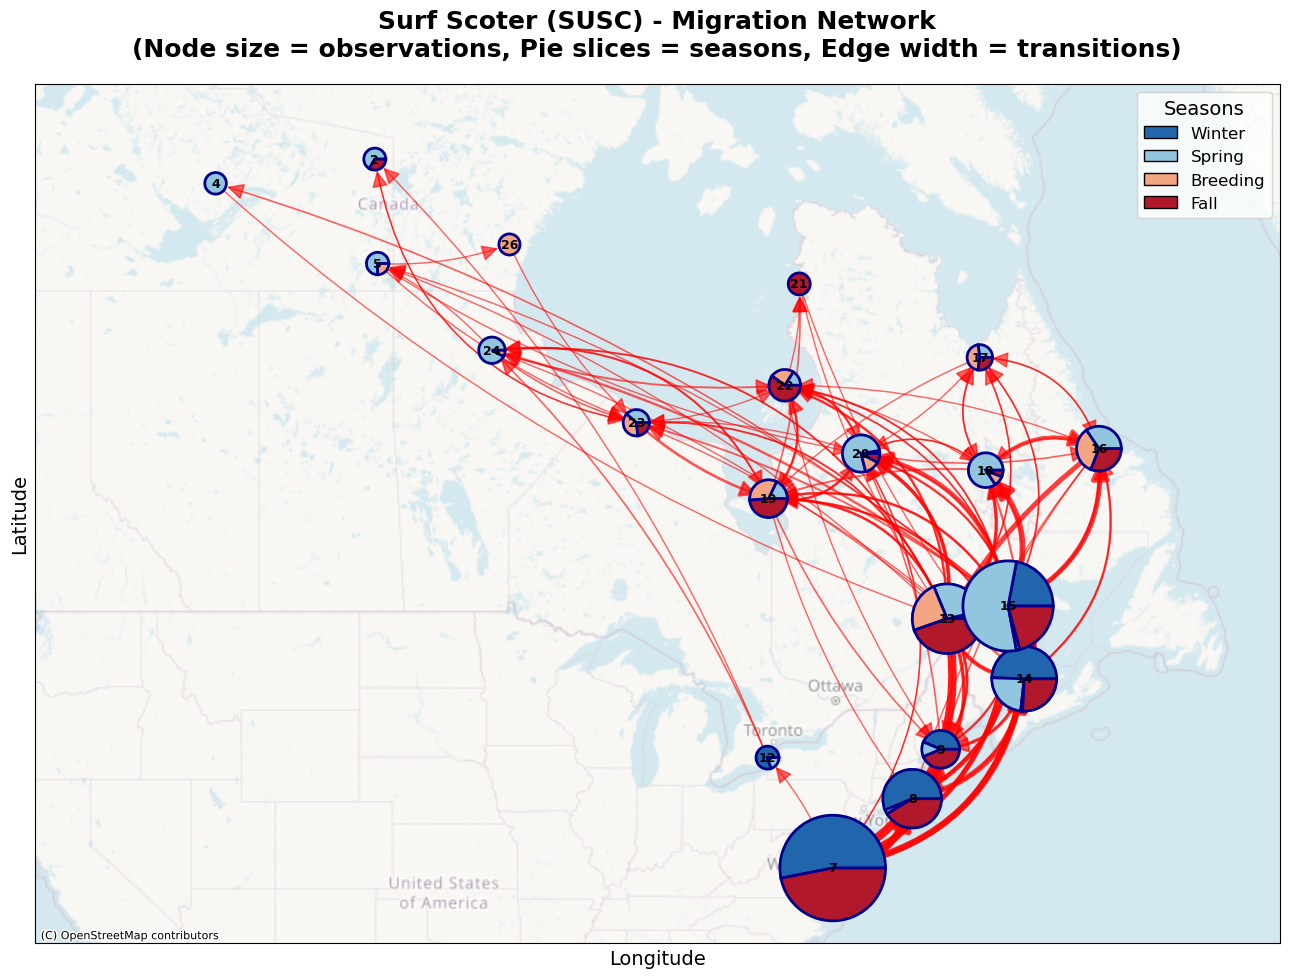

In [4]:
# %% [markdown]
# # Surf Scoter (SUSC) - Network Analysis
# Analisi della rete di migrazione per i Surf Scoters

# Filtra solo Surf Scoter 
df = df_full[df_full['species'] == 'SUSC'].copy()
print(f"Surf Scoters (SUSC)")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Surf Scoter (SUSC) - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()

Surf Scoters (SUSC) Males
Righe totali SUSC: 569
Individui unici: 71

Distribuzione per stagione (from_sea):
from_sea
F    192
W    167
S    167
B     43
Name: count, dtype: int64
Righe con next_cluster valido: 498
Righe dopo rimozione self-loops: 376

Cluster usati da BLSC: [np.int64(2), np.int64(7), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Numero di cluster: 17
Numero di link unici: 102

Top 10 link:
    source  target  weight
36      14      15      28
21      13       7      19
49      15      18      13
5        7      14      12
8        8       7      12
11       8      14      11
56      16      13      11
32      14       7      10
45      15      13       9
47      15      16       9
Peso dei cluster (numero osservazioni):
    cluster  total_weight
1         7           111
7        15            89
6        14 

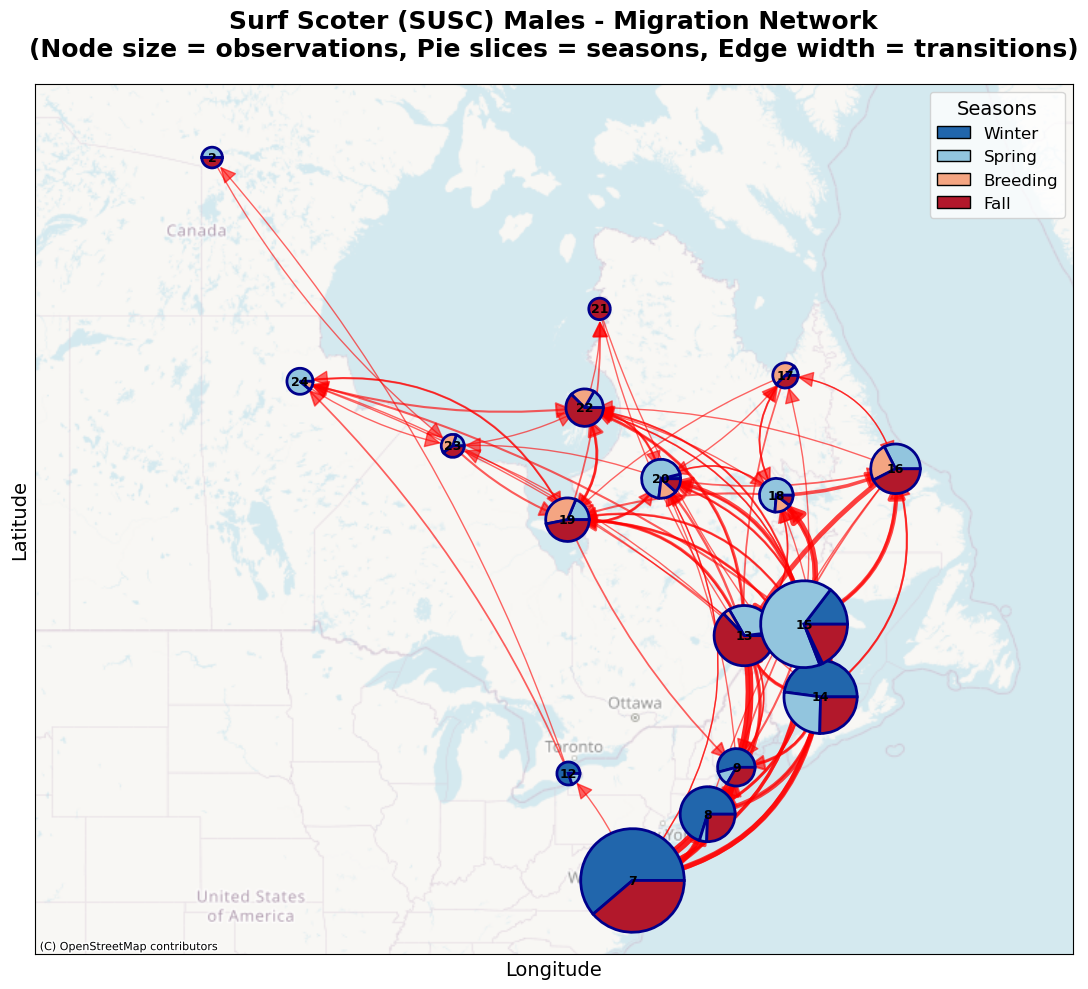

In [5]:
# %% [markdown]
# # Surf Scoter (SUSC) Males - Network Analysis
# Analisi della rete di migrazione per i Surf Scoters

# Filtra solo Surf Scoter 
df = df_full[(df_full['species'] == 'SUSC') & (df_full['sex'] == 'M')].copy()
print(f"Surf Scoters (SUSC) Males")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Surf Scoter (SUSC) Males - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()

Surf Scoters (SUSC) Females
Righe totali SUSC: 367
Individui unici: 61

Distribuzione per stagione (from_sea):
from_sea
F    127
S     98
W     96
B     46
Name: count, dtype: int64
Righe con next_cluster valido: 306
Righe dopo rimozione self-loops: 248

Cluster usati da BLSC: [np.int64(2), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(26)]
Numero di cluster: 18
Numero di link unici: 72

Top 10 link:
    source  target  weight
4        7       8      12
9        8       7      11
33      14      15      11
8        7      15      10
20      13       7      10
7        7      14       9
60      20      13       9
40      15       8       8
42      15      13       8
30      14       7       7
Peso dei cluster (numero osservazioni):
    cluster  total_weight
3         7            83
8        15            70

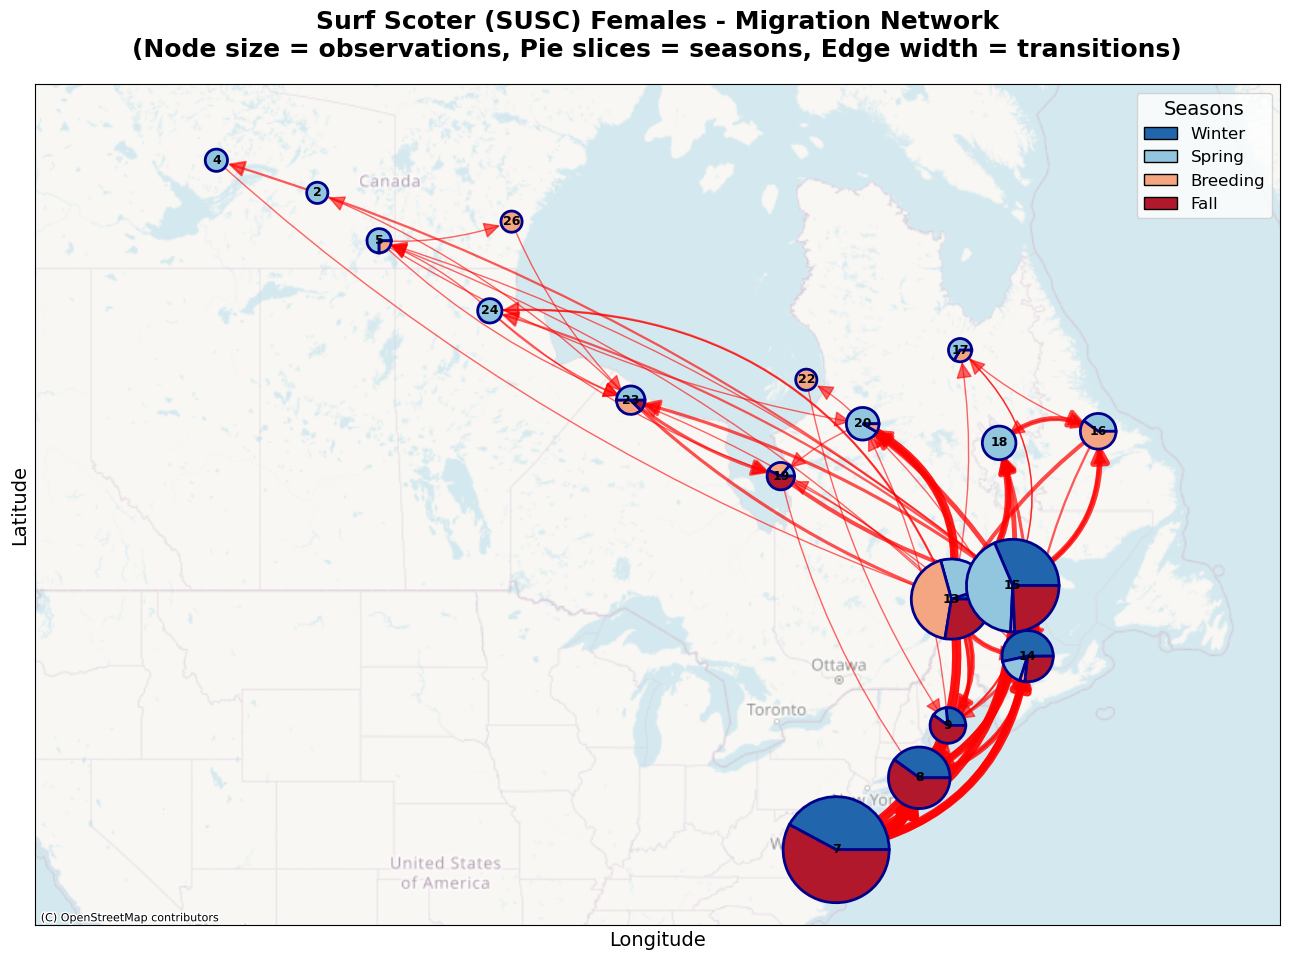

In [6]:
# %% [markdown]
# # Surf Scoter (SUSC) Females - Network Analysis
# Analisi della rete di migrazione per i Surf Scoters

# Filtra solo Surf Scoter 
df = df_full[(df_full['species'] == 'SUSC') & (df_full['sex'] == 'F')].copy()
print(f"Surf Scoters (SUSC) Females")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Surf Scoter (SUSC) Females - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()